## Stock Price Prediction (Short-Term)

## Objective
To predict the next day's closing stock price using historical data.

## Tools Used
- yfinance
- pandas
- scikit-learn
- matplotlib

In [1]:
!pip install yfinance scikit-learn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 684.4 kB/s eta 0:00:02
   ------------------- -------------------- 0.8/1.6 MB 684.4 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.6 MB 662.5 kB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 745.8 kB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 745.8 kB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 745.8 kB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 670.8 kB/s eta 0:00:00
  Creat

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## Step 1: Load Stock Data

We fetch historical data using yfinance.

In [3]:
# Choose stock (Apple)
stock = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928093,72.533133,71.708733,72.277617,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


## Step 2: Prepare Dataset

We use Open, High, Low, Volume to predict next day's Close.

In [4]:
# Create target (next day's close)
stock['Next_Close'] = stock['Close'].shift(-1)

# Drop last row (NaN)
stock = stock.dropna()

stock.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,71.696632
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,72.267944
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,71.928093
2020-01-07,71.928093,72.533133,71.708733,72.277617,108872000,73.085098
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,74.637489


## Step 3: Define Features and Target

In [5]:
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']

## Step 4: Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## Step 5: Train Linear Regression Model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 6: Make Predictions

In [8]:
y_pred = model.predict(X_test)

## Step 7: Evaluate Model

In [9]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4.9459538233515765


## Step 8: Plot Actual vs Predicted Prices

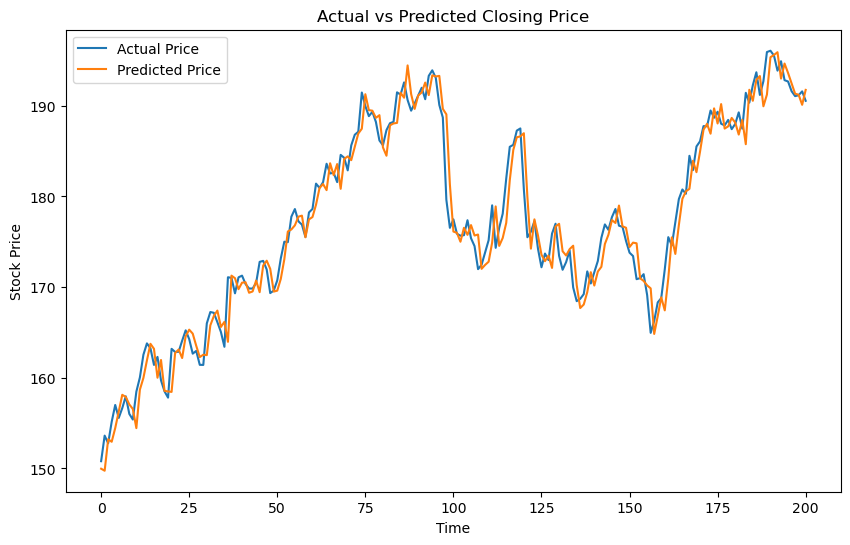

In [10]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

## Bonus: Random Forest Model

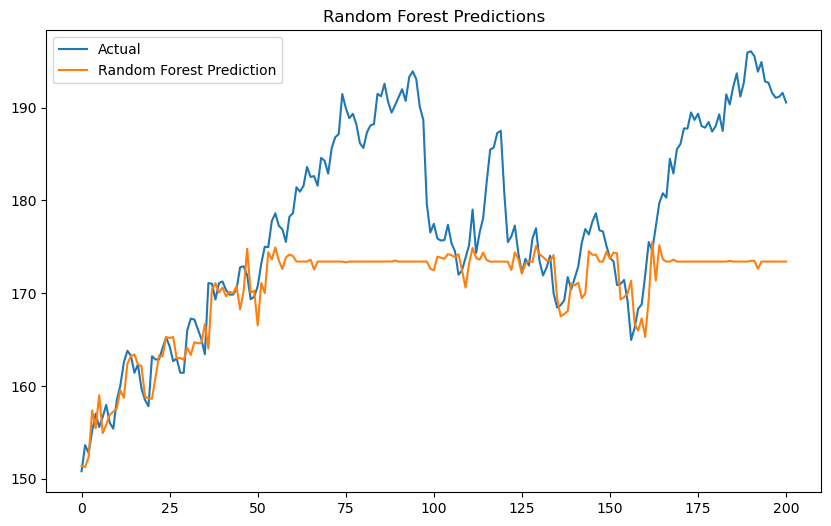

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='Random Forest Prediction')
plt.legend()
plt.title("Random Forest Predictions")
plt.show()